In [1]:
import sys
import os
sys.path.insert(0, os.path.expanduser('~/.local/lib/python3.9/site-packages'))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import gzip
import seaborn as sns 
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [3]:
FILTERED_VCF = "/scratch/jo11/NeoTrio_RNA_variants/filtered_vcfs"

In [4]:
## Track non-synonymous mutations in RNA

In [5]:
sequenza_df = pd.read_excel("/scratch/jo11/NeoTrio_RNA_variants/sequenza_braf_vaf.xlsx")
sequenza_df

syn_coords_df = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/NeoTrio_TMB_variant_coords.tsv", sep = "\t")
syn_coords_df.head()

,Chromosome,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Hugo_Symbol,IMPACT,Variant_Classification,HGVSp_Short,t_alt_count,t_depth,t_var_freq,sample_id
0,chr1,1182900,1182900,C,T,TTLL10,MODERATE,Missense_Mutation,p.P314L,9,36,0.250000,1
1,chr1,11529686,11529686,G,A,DISP3,MODERATE,Missense_Mutation,p.V977M,8,45,0.177778,1
2,chr1,13513473,13513473,C,T,LRRC38,MODERATE,Missense_Mutation,p.D41N,4,59,0.067797,1
3,chr1,19161677,19161677,T,C,UBR4,MODERATE,Missense_Mutation,p.K1696R,16,73,0.219178,1
4,chr1,27550626,27550626,G,A,AHDC1,MODERATE,Missense_Mutation,p.S497F,13,55,0.236364,1


In [6]:
syn_coords_df['sample_id'] = syn_coords_df['sample_id'].map(
    sequenza_df.set_index('maf_number')['melpin'])

In [7]:
syn_coords_df['sample_id'] = syn_coords_df['sample_id'].str.replace(r'(PRE|EDT1|ED2|CLND)[-_]?', '', regex=True)
syn_coords_df.rename(columns={'sample_id': 'melpin'}, inplace=True)

In [8]:
syn_coords_df.head()
syn_coords_df['melpin'] = syn_coords_df['melpin'].astype(int)

In [9]:
OUTPUT_DIR = "/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap"
os.makedirs(OUTPUT_DIR, exist_ok=True)

timepoint_map = {
    "PRE": "Baseline",
    "ED1": "Week 1",
    "ED2": "Week 2",
    "CLND": "Week 6",
    "PRO": "Progressed",
    "PROG": "Progressed",
}
tp_order = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def extract_vaf_dp(fields):
    """Parse AD and DP from VCF FORMAT and SAMPLE columns."""
    format_keys = fields[8].split(":")
    sample_values = fields[9].split(":")
    fmt = dict(zip(format_keys, sample_values))

    vaf = None
    ref_reads = None
    alt_reads = None
    dp = None

    if "AD" in fmt:
        ad = fmt["AD"].split(",")
        try:
            ref_reads = int(ad[0])
            alt_reads = int(ad[1])
            total = ref_reads + alt_reads
            vaf = alt_reads / total if total > 0 else None
        except (ValueError, IndexError):
            pass

    if "DP" in fmt:
        try:
            dp = int(fmt["DP"])
        except ValueError:
            pass

    return vaf, ref_reads, alt_reads, dp

def parse_vcf_for_loci(vcf_path, loci_set):
    """Read VCF once but only keep loci we care about."""
    results = {}
    with open(vcf_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.strip().split("\t")
            chrom = fields[0]
            pos = int(fields[1])
            if (chrom, pos) in loci_set:
                filt = fields[6]
                vaf, _, _, dp = extract_vaf_dp(fields)
                results[(chrom, pos)] = (vaf if vaf and filt == "PASS" else 0.0, dp)
    return results

def get_variant_retention(syn_coords_df, vcf_dir=FILTERED_VCF, n_workers=8):
    all_melpins = sorted(syn_coords_df['melpin'].unique())
    vcf_paths = sorted(glob.glob(os.path.join(vcf_dir, "*.filtered.vcf")))

    # Build global loci set from ALL patients
    all_loci = set(zip(syn_coords_df['Chromosome'], syn_coords_df['Start_Position']))

    print(f"Parsing {len(vcf_paths)} VCFs with {n_workers} threads for {len(all_loci)} loci...")
    vcf_cache = {}

    def worker(vcf_path):
        filename = os.path.basename(vcf_path)
        match = re.match(r"^(\d+)(CLND|PROG|PRO|PRE|ED1|ED2)", filename, re.IGNORECASE)
        if not match:
            return None
        patient_id = int(match.group(1))
        tp_key = match.group(2).upper()
        tp_label = timepoint_map.get(tp_key, "Unknown")
        parsed = parse_vcf_for_loci(vcf_path, all_loci)
        return (patient_id, tp_label, parsed)

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(worker, p): p for p in vcf_paths}
        for i, future in enumerate(as_completed(futures), 1):
            result = future.result()
            if result:
                patient_id, tp_label, parsed = result
                vcf_cache[(patient_id, tp_label)] = parsed
            if i % 50 == 0 or i == len(vcf_paths):
                print(f"  {i}/{len(vcf_paths)} done")

    print(f"Cached {len(vcf_cache)} VCFs.\n")

    summary_rows = []
    for melpin in all_melpins:
        patient_loci = syn_coords_df[syn_coords_df['melpin'] == int(melpin)]
        if patient_loci.empty:
            continue
        loci_set = set(zip(patient_loci['Chromosome'], patient_loci['Start_Position']))
        n_loci = len(loci_set)
        row = {'Patient': melpin, 'n_loci': n_loci}
        for tp in tp_order:
            if (melpin, tp) not in vcf_cache:
                row[tp] = np.nan
            else:
                parsed = vcf_cache[(melpin, tp)]
                n_present = sum(1 for loc in loci_set if parsed.get(loc, (0.0, None))[0] > 0)
                row[tp] = n_present / n_loci
        summary_rows.append(row)

    return pd.DataFrame(summary_rows)


In [11]:
df_retention = get_variant_retention(syn_coords_df, vcf_dir=FILTERED_VCF, n_workers=8)

Parsing 223 VCFs with 8 threads for 14896 loci...
  50/223 done
  100/223 done
  150/223 done
  200/223 done
  223/223 done
Cached 223 VCFs.



In [24]:
df_retention.to_csv('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/variant_retention_summary.csv', index=False)

In [13]:
df_retention

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385


In [14]:
rna_meta = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/counts_rna_meta_full.csv")
rna_meta

,Unnamed: 0,MelPin,DOB,GENDER,Nodal.Basin,V600,PROG.Pre.Sx,PROG.Post.Sx,ARM,Timepoint,pCR..Y...1..N...0.,path.response..1.pCR.2.npCR.3.pPR.4.pNR.,Major.Path.Response..pCR.npCR.1.pPR.pNR.0.,Any.Response..pCR.npCR.PR...1..NR.0.,Suffix,clinical_mapping
0,1,9999_S0,8/01/1968,F,AXILLA,E,0.0,N,CON,0,0,3,0,1,_S0,PRE
1,2,9999_S1,8/01/1968,F,AXILLA,E,0.0,N,CON,1,0,3,0,1,_S1,ED1
2,3,9999_S2,8/01/1968,F,AXILLA,E,0.0,N,CON,2,0,3,0,1,_S2,ED2
3,4,9999_S3,8/01/1968,F,AXILLA,E,0.0,N,CON,3,0,3,0,1,_S3,CLND
4,5,16518_S0,1959-06-12,M,GROIN,E,0.0,Y,CON,0,0,4,0,0,_S0,PRE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,219,43463_S4,1955-08-31,M,GROIN,E,0.0,Y,SEQ,4,0,4,0,0,_S4,PROG
219,220,53620_S4,1976-04-26,M,GROIN,K,0.0,Y,ALONE,4,0,3,0,1,_S4,PROG
220,221,55314_S4,1981-12-08,M,GROIN,E,NaN,Y,SEQ,4,0,4,0,0,_S4,PROG
221,222,50861_S2,1958-07-25,M,NECK,E,0.0,Y,ALONE,2,0,4,0,0,_S0,PRE


In [15]:
rna_meta.rename(columns={'MelPin': 'melpin'}, inplace=True)
rna_meta["melpin"] = rna_meta["melpin"].astype(str).str.replace(r"_S\d+$", "", regex=True)
df_retention['Patient'] = df_retention['Patient'].astype(str)
# Verify the fix
print("meta MelPin samples:", rna_meta["melpin"].unique()[:5])

patient_meta = rna_meta.drop_duplicates(subset="melpin").set_index("melpin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

any_resp_map = {1: "Responder", 0: "Non-responder"}
patient_meta["AnyResponse"] = patient_meta["Any.Response..pCR.npCR.PR...1..NR.0."].map(any_resp_map)

tmb_df = df_retention.merge(
    patient_meta[["Response", "MPR", "AnyResponse", "ARM"]].reset_index(),
    left_on="Patient",
    right_on="melpin",
    how="left",
)
tmb_df 

meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN,36029,pCR,MPR,Responder,CON
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN,43306,pNR,NMPR,Non-responder,SEQ
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ


In [16]:
retention_annotated = tmb_df
sequenza_df['melpin_clean'] = sequenza_df['melpin'].str.replace(r'(PRE|ED1|ED2|CLND|PRO|PROG)', '', regex=True)

retention_annotated = retention_annotated.merge(
    sequenza_df[['melpin_clean', 'cellularity', 'ploidy', 'braf_v600_AF']].drop_duplicates(subset='melpin_clean'),
    left_on='Patient',
    right_on='melpin_clean',
    how='left',
).drop(columns='melpin_clean')

retention_annotated.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907


In [17]:
braf_status = pd.read_csv("/scratch/jo11/NeoTrio_RNA_variants/braf_status.csv")
braf_status['melpin'] = braf_status['melpin'].astype(str)
braf_status = braf_status.drop_duplicates(subset='melpin')

retention_annotated = retention_annotated.merge(
    braf_status[['melpin', 'BRAF_status']],
    left_on='Patient',
    right_on='melpin',
    how='left',
).drop(columns='melpin_y').rename(columns={'melpin_x': 'melpin'})

retention_annotated.head()

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E


In [18]:
retention_annotated

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
2,18369,515,0.219417,0.104854,0.001942,0.000000,NaN,18369,pCR,MPR,Responder,CON,0.15,2.0,0.411290,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E
5,36029,5,0.000000,0.000000,0.000000,0.000000,NaN,36029,pCR,MPR,Responder,CON,0.14,1.8,0.000000,V600E
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ,0.81,2.1,0.638554,V600E
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE,0.96,2.0,0.962963,V600E
8,43306,488,0.231557,0.133197,0.022541,0.389344,NaN,43306,pNR,NMPR,Non-responder,SEQ,0.10,2.3,0.166667,V600K/R
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ,0.85,2.9,0.511111,V600E


In [19]:
print(f"Total patients: {len(retention_annotated)}\n")

options = {
    "Original (AF>0 & cell≥0.2)": 
        (retention_annotated['braf_v600_AF'] > 0) & (retention_annotated['cellularity'] >= 0.2),
    "Option 1 (AF>0 & cell≥0.1)": 
        (retention_annotated['braf_v600_AF'] > 0) & (retention_annotated['cellularity'] >= 0.1),
    "Option 2 (cell≥0.2 only)": 
        retention_annotated['cellularity'] >= 0.2,
    "Option 3 (cell≥0.2 OR AF>0)": 
        (retention_annotated['cellularity'] >= 0.2) | (retention_annotated['braf_v600_AF'] > 0),
}

for name, mask in options.items():
    kept = retention_annotated[mask]
    n_mpr = (kept['MPR'] == 'MPR').sum()
    n_nmpr = (kept['MPR'] == 'NMPR').sum()
    print(f"{name}: kept {len(kept)} | dropped {len(retention_annotated) - len(kept)} | MPR: {n_mpr} | NMPR: {n_nmpr}")

Total patients: 60

Original (AF>0 & cell≥0.2): kept 40 | dropped 20 | MPR: 13 | NMPR: 27
Option 1 (AF>0 & cell≥0.1): kept 49 | dropped 11 | MPR: 17 | NMPR: 32
Option 2 (cell≥0.2 only): kept 49 | dropped 11 | MPR: 19 | NMPR: 30
Option 3 (cell≥0.2 OR AF>0): kept 58 | dropped 2 | MPR: 23 | NMPR: 35


In [20]:
retention_filtered = retention_annotated[
    (retention_annotated['braf_v600_AF'] > 0) & 
    (retention_annotated['cellularity'] >= 0.2)
].copy()

In [21]:
retention_filtered

,Patient,n_loci,Baseline,Week 1,Week 2,Week 6,Progressed,melpin,Response,MPR,AnyResponse,ARM,cellularity,ploidy,braf_v600_AF,BRAF_status
0,9999,24,0.333333,0.083333,0.083333,0.041667,NaN,9999,pPR,NMPR,Responder,CON,0.27,1.9,0.063830,V600E
1,16518,340,0.305882,0.226471,0.061765,0.394118,NaN,16518,pNR,NMPR,Non-responder,CON,0.29,1.7,0.266667,V600E
3,24799,110,0.372727,0.400000,0.381818,NaN,NaN,24799,pNR,NMPR,Non-responder,CON,0.79,2.0,0.423529,V600E
4,28248,667,0.379310,0.271364,0.266867,0.247376,0.394303,28248,pNR,NMPR,Non-responder,SEQ,0.61,2.1,0.627907,V600E
6,37747,162,0.432099,NaN,0.475309,0.246914,NaN,37747,pNR,NMPR,Non-responder,SEQ,0.81,2.1,0.638554,V600E
7,39330,253,0.446640,0.513834,0.498024,0.494071,NaN,39330,pNR,NMPR,Non-responder,ALONE,0.96,2.0,0.962963,V600E
9,43463,52,0.442308,0.384615,0.365385,0.384615,0.365385,43463,pNR,NMPR,Non-responder,SEQ,0.85,2.9,0.511111,V600E
10,45212,511,0.193738,0.007828,0.138943,0.348337,NaN,45212,pPR,NMPR,Responder,CON,0.62,3.1,0.458333,V600E
15,48234,188,0.531915,0.377660,0.489362,0.547872,NaN,48234,pNR,NMPR,Non-responder,ALONE,0.64,2.3,0.414141,V600E
16,48551,548,0.264599,0.140511,0.000000,0.000000,NaN,48551,pCR,MPR,Responder,SEQ,0.82,2.0,0.678571,V600E


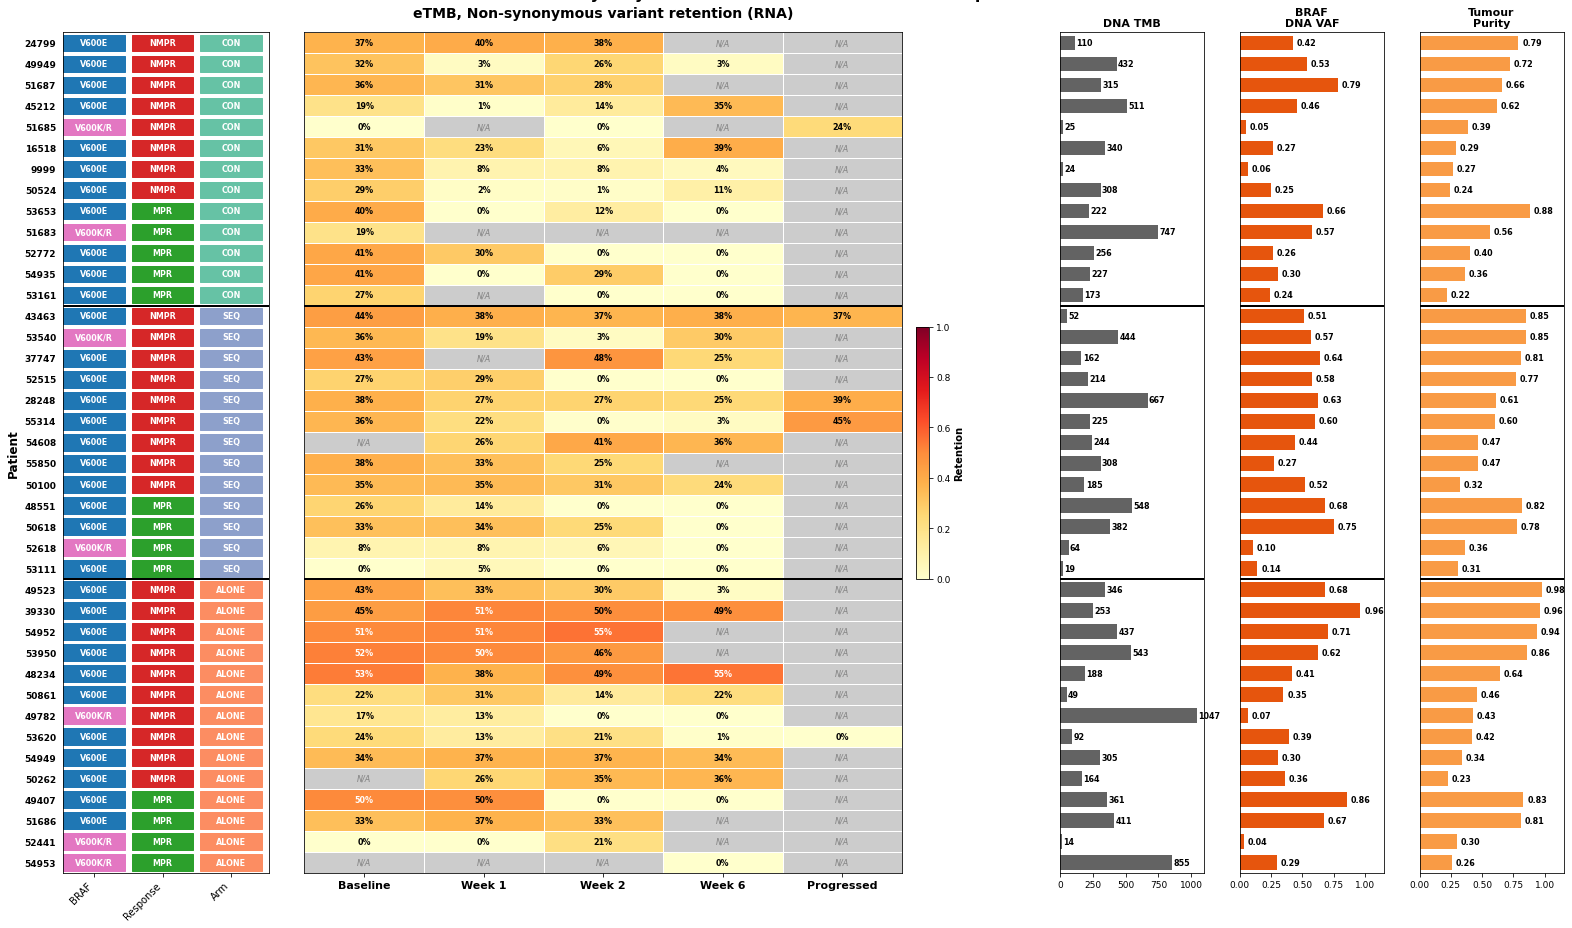

In [32]:
tp_cols = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

# Sort by treatment arm, response and sort tP
retention_filtered['ARM'] = pd.Categorical(retention_filtered['ARM'], categories=['CON', 'SEQ', 'ALONE'], ordered=True)
retention_filtered['MPR'] = pd.Categorical(retention_filtered['MPR'], categories=['NMPR', 'MPR'], ordered=True)
plot_df = retention_filtered.sort_values(['ARM', 'MPR', 'cellularity'], ascending=[True, True, False]).reset_index(drop=True)

heatmap_data = plot_df[tp_cols].values.astype(float)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#cccccc')

# set dims 
n_patients = len(plot_df)
row_height = 0.25
fig_height = max(10, n_patients * row_height + 3)

fig, axes = plt.subplots(1, 5, figsize=(22, fig_height),
                          gridspec_kw={'width_ratios': [1, 3.5, 0.7, 0.7, 0.7]},
                          sharey=True)

ax_ann = axes[0]
ax_ann.set_xlim(0, 3)
ax_ann.set_ylim(-0.5, n_patients - 0.5)
ax_ann.invert_yaxis()

arm_colors = {'CON': '#66c2a5', 'SEQ': '#8da0cb', 'ALONE': '#fc8d62'}
mpr_colors = {'MPR': '#2ca02c', 'NMPR': '#d62728'}
braf_colors = {'V600E': '#1f77b4', 'V600K/R': '#e377c2'}

for i, row in plot_df.iterrows():
    ax_ann.add_patch(plt.Rectangle((0, i - 0.4), 0.9, 0.8, color=braf_colors.get(row['BRAF_status'], 'grey')))
    ax_ann.text(0.45, i, row['BRAF_status'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax_ann.add_patch(plt.Rectangle((1.0, i - 0.4), 0.9, 0.8, color=mpr_colors.get(row['MPR'], 'grey')))
    ax_ann.text(1.45, i, row['MPR'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax_ann.add_patch(plt.Rectangle((2.0, i - 0.4), 0.9, 0.8, color=arm_colors.get(row['ARM'], 'grey')))
    ax_ann.text(2.45, i, row['ARM'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax_ann.set_xticks([0.45, 1.45, 2.45])
ax_ann.set_xticklabels(['BRAF', 'Response', 'Arm'], fontsize=10, rotation=45, ha='right')
ax_ann.set_yticks(range(n_patients))
ax_ann.set_yticklabels(plot_df['Patient'].astype(str), fontsize=9, fontweight='bold')
ax_ann.tick_params(left=False)
ax_ann.set_ylabel('Patient', fontsize=12, fontweight='bold')

# Arm group separators
prev_arm = None
for i, row in plot_df.iterrows():
    if prev_arm is not None and row['ARM'] != prev_arm:
        for ax in axes:
            ax.axhline(i - 0.5, color='black', linewidth=2)
    prev_arm = row['ARM']

# --- Panel 1: Retention heatmap (eTMB) ---
ax_heat = axes[1]
masked_data = np.ma.masked_invalid(heatmap_data)
im = ax_heat.pcolormesh(np.arange(len(tp_cols) + 1), np.arange(n_patients + 1) - 0.5,
                         masked_data, cmap=cmap, vmin=0, vmax=1, edgecolors='white', linewidth=0.5)

for i in range(n_patients):
    for j in range(len(tp_cols)):
        val = heatmap_data[i, j]
        if np.isnan(val):
            ax_heat.text(j + 0.5, i, 'N/A', ha='center', va='center', fontsize=8, color='grey', style='italic')
        else:
            color = 'white' if val > 0.5 else 'black'
            ax_heat.text(j + 0.5, i, f'{val:.0%}', ha='center', va='center', fontsize=8, color=color, fontweight='bold')

ax_heat.set_xticks(np.arange(len(tp_cols)) + 0.5)
ax_heat.set_xticklabels(tp_cols, fontsize=11, fontweight='bold')
ax_heat.set_title('eTMB, Non-synonymous variant retention (RNA)', fontsize=14, fontweight='bold', pad=15)
ax_heat.tick_params(left=False)

# --- Panel 2: DNA TMb---
ax_nloci = axes[2]
ax_nloci.barh(range(n_patients), plot_df['n_loci'], color='#636363', height=0.7)
for i, val in enumerate(plot_df['n_loci']):
    ax_nloci.text(val + 10, i, str(val), va='center', fontsize=8, fontweight='bold')
ax_nloci.set_title('DNA TMB', fontsize=11, fontweight='bold')
ax_nloci.tick_params(left=False)
ax_nloci.set_xlabel('')
ax_nloci.tick_params(axis='x', labelsize=9)

# --- Panel 3: BRAF DNA VAF ---
ax_braf = axes[3]
ax_braf.barh(range(n_patients), plot_df['braf_v600_AF'], color='#e6550d', height=0.7)
for i, val in enumerate(plot_df['braf_v600_AF']):
    ax_braf.text(val + 0.03, i, f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax_braf.set_xlim(0, 1.15)
ax_braf.set_title('BRAF\nDNA VAF', fontsize=11, fontweight='bold')
ax_braf.tick_params(left=False)
ax_braf.tick_params(axis='x', labelsize=9)

# --- Panel 4: Cellularity ---
ax_cell = axes[4]
ax_cell.barh(range(n_patients), plot_df['cellularity'], color='#f99b45', height=0.7)
for i, val in enumerate(plot_df['cellularity']):
    ax_cell.text(val + 0.03, i, f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax_cell.set_xlim(0, 1.15)
ax_cell.set_title('Tumour\nPurity', fontsize=11, fontweight='bold')
ax_cell.tick_params(left=False)
ax_cell.tick_params(axis='x', labelsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=axes[1], shrink=0.3, pad=0.02)
cbar.set_label('Retention', fontsize=10, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

plt.suptitle('Nonsynonymous Variant Retention Across Timepoints', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('/scratch/jo11/NeoTrio_RNA_variants/non_synonym_heatmap/cohort_retention_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()